In [1]:
library(dplyr)
library(GenomicRanges)
library(ggplot2)
library(readr)
library(readxl)

dir.create("../../outputs/Extended/", recursive = TRUE, showWarnings = FALSE)

dir.create("../../outputs/Extended/Ext-Data-Fig-7-Response-PCs", recursive = TRUE, showWarnings = FALSE)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, saveRDS, setdiff,
    table, tapply, union, unique, unsplit, which.max, which.min


Loading required package: S4Vectors


Attachi

In [2]:
features_df5 <- read_csv("../../data/Extended/delfi_long_df_final_analysis_df.csv")

Rows: 71 Columns: 539
── Column specification ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr  (12): id, Patient, Timepoint ID, Timepoint Significance, Initial radiog...
dbl (527): zscore_1p, zscore_1q, zscore_2p, zscore_2q, zscore_3p, zscore_3q,...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


## Plotting features

In [3]:
library(ggplot2)
library(patchwork)

plot_patient_trajectory <- function(df, patient, pc_col,
                                     days_col    = "Days from Treatment",
                                     maf_col     = "Maximum Mutant Allele Fractionᶥ",
                                     patient_col = "Patient",
                                     treatment_day = 0,
                                     invert_pc = FALSE,
                                     maf_color = "#E8820E",
                                     pc_color  = "#B22222") {

  d <- df[df[[patient_col]] == patient, ]
  d <- d[order(d[[days_col]]), ]

  # recycle invert_pc to match length of pc_col if a single value was given
  if (length(invert_pc) == 1) {
    invert_pc <- rep(invert_pc, length(pc_col))
  }
  if (length(invert_pc) != length(pc_col)) {
    stop("invert_pc must be length 1 or the same length as pc_col")
  }

  base <- theme_classic(base_size = 20) +
    theme(axis.title.x = element_blank(),
          axis.text    = element_text(color = "black"),
          plot.margin  = margin(4, 10, 2, 6))

  arrow_layer <- function(ytop) annotate(
    "segment", x = treatment_day, xend = treatment_day,
    y = ytop * 1.18, yend = ytop * 1.02,
    arrow = arrow(length = unit(0.18, "cm"), type = "closed"),
    linewidth = 0.9, color = "black")

  maf_max <- max(d[[maf_col]], na.rm = TRUE)

  p_top <- ggplot(d, aes(.data[[days_col]], .data[[maf_col]])) +
    geom_line(color = maf_color, linewidth = 0.7) +
    geom_point(color = maf_color, size = 2.6) +
    arrow_layer(maf_max) +
    coord_cartesian(clip = "off", ylim = c(0, maf_max * 1.18)) +
    labs(y = "MAF (%)", title = patient) +
    base + theme(plot.title = element_text(hjust = 0.5, face = "bold"))

  # one panel per PC column
  pc_panels <- Map(function(col, inv) {
    d$.pc_val <- if (inv) -1 * d[[col]] else d[[col]]
    pc_label  <- if (inv) paste0("", col) else col

    ggplot(d, aes(.data[[days_col]], .pc_val)) +
      geom_line(color = pc_color, linewidth = 0.7) +
      geom_point(color = pc_color, size = 2.6) +
      labs(y = pc_label, x = "Days from treatment") +
      theme_classic(base_size = 20) +
      theme(axis.text = element_text(color = "black"),
            plot.margin = margin(2, 10, 4, 6))
  }, pc_col, invert_pc)

  # only the bottom-most panel keeps the x-axis title
  if (length(pc_panels) > 1) {
    for (i in seq_len(length(pc_panels) - 1)) {
      pc_panels[[i]] <- pc_panels[[i]] + theme(axis.title.x = element_blank())
    }
  }

  all_panels <- c(list(p_top), pc_panels)
  wrap_plots(all_panels, ncol = 1) + plot_layout(heights = rep(1, length(all_panels)))
}

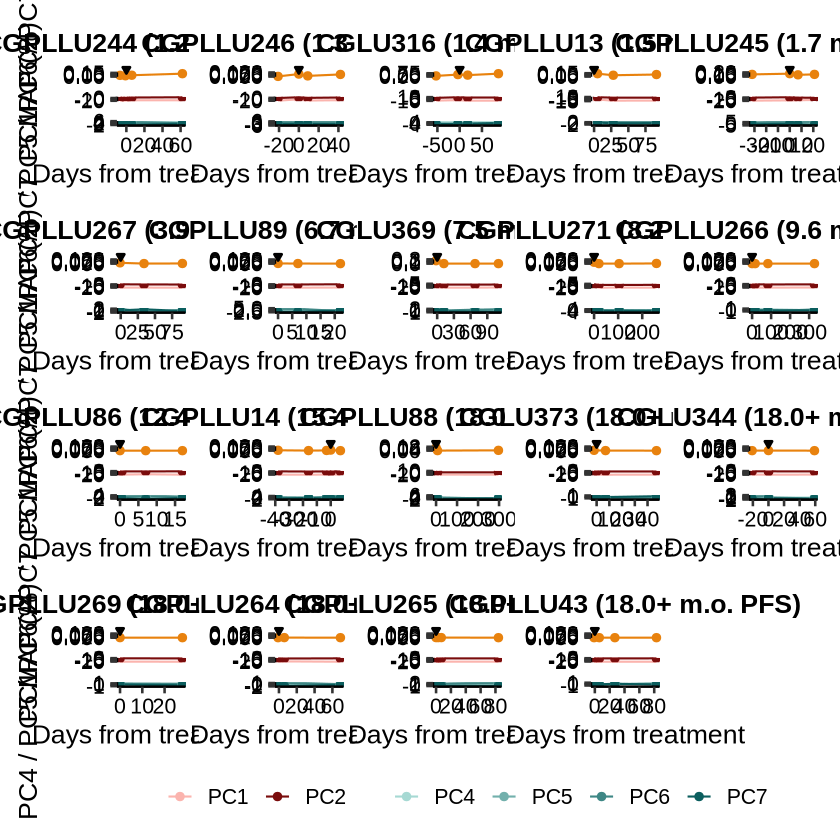

In [4]:
plot_patient_trajectory <- function(df, patient, pc_groups,
                                     days_col    = "Days from Treatment",
                                     maf_col     = "Maximum Mutant Allele Fractionᶥ",
                                     patient_col = "Patient",
                                     treatment_day = 0,
                                     invert_pc = FALSE,
                                     score_type = c("raw", "pct_change", "zscore", "healthy_dev"),
                                     healthy_df = NULL,
                                     healthy_type_col = "type",
                                     healthy_type_val = "healthy",
                                     maf_color = "#E8820E",
                                     maf_min_top = NULL,
                                     pc_min_span = NULL,
                                     group_colors = NULL,
                                     base_size = 14,
                                     show_legend = TRUE,
                                     title_label = NULL,
                                     row_spacing = 10,
                                     maf_pc_spacing = 10,     # <- space between MAF panel and PC1/2 panel
                                     pc_group_spacing = 22) { # <- space between PC1/2 panel and PC4/5/6/7 panel

  score_type <- match.arg(score_type)
  if (score_type == "healthy_dev" && is.null(healthy_df)) stop("healthy_df must be provided when score_type = 'healthy_dev'")

  d <- df[df[[patient_col]] == patient, ]
  d <- d[order(d[[days_col]]), ]

  d_maf <- d[!is.na(d[[maf_col]]) & !is.na(d[[days_col]]), ]

  # ---- FIX #2: x-range now always includes treatment_day, so the arrow never falls outside xlim ----
  x_range <- range(c(d[[days_col]], treatment_day), na.rm = TRUE)

  if (!is.list(pc_groups)) pc_groups <- as.list(pc_groups)
  group_sizes <- lengths(pc_groups)
  flat_pc <- unlist(pc_groups)

  if (length(invert_pc) == 1) {
    invert_pc_flat <- rep(invert_pc, length(flat_pc))
  } else if (length(invert_pc) == length(flat_pc)) {
    invert_pc_flat <- invert_pc
  } else {
    stop("invert_pc must be length 1 or match the total number of PCs across all pc_groups")
  }
  invert_groups <- split(invert_pc_flat, rep(seq_along(pc_groups), group_sizes))

  pc_short_name <- function(col) paste0("PC", as.integer(gsub("\\D", "", col)))

  default_families <- list(
    c("#FBB4AE", "#7A0C0C"),
    c("#A6D9D3", "#0B5E5E"),
    c("#C9B8E8", "#4B2E83"),
    c("#FDD9A0", "#9C5A00"),
    c("#BFD9BF", "#1B5E20")
  )
  if (is.null(group_colors)) {
    group_colors <- lapply(seq_along(pc_groups), function(i) {
      fam <- default_families[[((i - 1) %% length(default_families)) + 1]]
      n <- group_sizes[i]
      if (n == 1) fam[2] else colorRampPalette(fam)(n)
    })
  }

  no_x_axis <- theme(
    axis.title.x = element_blank(),
    axis.text.x  = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line.x  = element_blank()
  )

  base <- theme_classic(base_size = base_size) +
    theme(axis.text = element_text(color = "black"),
          plot.margin = margin(row_spacing, 8, 0, 6)) +
    no_x_axis

  # ---- FIX #1: reserve dedicated headroom above the data for the arrow, independent of axis padding ----
  maf_max_this_patient <- max(d_maf[[maf_col]], na.rm = TRUE)
  data_pad_top <- maf_max_this_patient / 0.72     # data occupies ~72% of axis height
  y_top <- data_pad_top
  if (!is.null(maf_min_top)) y_top <- max(y_top, maf_min_top)

  arrow_layer <- function(ytop) annotate("segment", x = treatment_day, xend = treatment_day,
    y = ytop * 0.90, yend = ytop * 0.78,   # arrow occupies 78-90%, clear of data's ~72% ceiling
    arrow = arrow(length = unit(0.15, "cm"), type = "closed"),
    linewidth = 0.8, color = "black")

  plot_title <- if (!is.null(title_label)) title_label else patient

  p_top <- ggplot(d_maf, aes(.data[[days_col]], .data[[maf_col]])) +
    geom_line(color = maf_color, linewidth = 0.6) +
    geom_point(color = maf_color, size = 2) +
    arrow_layer(y_top) +
    coord_cartesian(clip = "off", xlim = x_range, ylim = c(0, y_top)) +
    labs(y = "MAF (%)", title = plot_title) +
    base + theme(plot.title = element_text(hjust = 0.5, face = "bold", size = base_size))

  transform_one <- function(col, inv) {
    raw <- d[[col]]
    if (score_type == "raw") { val <- raw }
    else if (score_type == "pct_change") {
      base_idx <- which(d[[days_col]] <= treatment_day); if (length(base_idx) == 0) base_idx <- 1
      baseline <- mean(raw[base_idx], na.rm = TRUE)
      val <- (raw - baseline) / abs(baseline) * 100
    } else if (score_type == "zscore") { val <- as.numeric(scale(raw)) }
    else if (score_type == "healthy_dev") {
      h <- healthy_df[healthy_df[[healthy_type_col]] == healthy_type_val, ]
      h_mean <- mean(h[[col]], na.rm = TRUE); h_sd <- sd(h[[col]], na.rm = TRUE)
      val <- (raw - h_mean) / h_sd
    }
    if (inv) val <- -1 * val
    val
  }

  y_lab_suffix <- switch(score_type, raw = "", pct_change = "\n% change from baseline",
                          zscore = "\n(patient z-score)", healthy_dev = "\n(SD from healthy)")

  compute_dynamic_ylim <- function(vals, min_span, pad_frac = 0.10) {
    rng <- range(vals, na.rm = TRUE)
    span <- diff(rng)
    pad <- span * pad_frac
    ylim <- c(rng[1] - pad, rng[2] + pad)
    cur_span <- diff(ylim)
    if (!is.null(min_span) && cur_span < min_span) {
      center <- mean(ylim)
      ylim <- c(center - min_span / 2, center + min_span / 2)
    }
    ylim
  }

  pc_panels <- Map(function(cols, invs, cols_colors, min_span_i) {
    grp_long <- do.call(rbind, Map(function(col, inv) {
      data.frame(days = d[[days_col]], value = transform_one(col, inv), pc = pc_short_name(col))
    }, cols, invs))
    grp_long$pc <- factor(grp_long$pc, levels = sapply(cols, pc_short_name))

    ylim_i <- compute_dynamic_ylim(grp_long$value, min_span_i)

    if (length(cols) == 1) {
      p <- ggplot(grp_long, aes(days, value)) +
        geom_line(color = cols_colors, linewidth = 0.6) +
        geom_point(color = cols_colors, size = 2) +
        coord_cartesian(xlim = x_range, ylim = ylim_i) +
        labs(y = paste0(pc_short_name(cols), y_lab_suffix), x = "Days from treatment")
    } else {
      names(cols_colors) <- sapply(cols, pc_short_name)
      p <- ggplot(grp_long, aes(days, value, color = pc)) +
        geom_line(linewidth = 0.6) +
        geom_point(size = 2) +
        scale_color_manual(values = cols_colors, name = NULL) +
        coord_cartesian(xlim = x_range, ylim = ylim_i) +
        labs(y = paste0(paste(sapply(cols, pc_short_name), collapse = " / "), y_lab_suffix),
             x = "Days from treatment")
    }

    p <- p + theme_classic(base_size = base_size) +
      theme(axis.text = element_text(color = "black"), plot.margin = margin(0, 8, 0, 6))
    if (score_type %in% c("zscore", "healthy_dev", "pct_change")) {
      p <- p + geom_hline(yintercept = 0, linetype = "dashed", color = "grey50", linewidth = 0.4)
    }
    p
  }, pc_groups, invert_groups, group_colors,
     if (is.null(pc_min_span)) vector("list", length(pc_groups)) else pc_min_span)

  if (length(pc_panels) > 1) {
    for (i in seq_len(length(pc_panels) - 1)) {
      pc_panels[[i]] <- pc_panels[[i]] + no_x_axis
    }
  }

  # ---- spacing between panels ----
  group_top_spacing <- c(maf_pc_spacing, rep(pc_group_spacing, max(0, length(pc_panels) - 1)))
  for (i in seq_along(pc_panels)) {
    bottom_i <- if (i == length(pc_panels)) 4 else 0
    pc_panels[[i]] <- pc_panels[[i]] +
      theme(plot.margin = margin(group_top_spacing[i], 8, bottom_i, 6))
  }

  all_panels <- c(list(p_top), pc_panels)
  combined <- wrap_plots(all_panels, ncol = 1) + plot_layout(heights = rep(1, length(all_panels)))

  if (!show_legend) {
    combined <- combined & theme(legend.position = "none")
  }
  combined
}

# =====================================================================
# Cohort-level wrapper: arranges patients in a grid, keeps y-axis
# text/ticks/line in EVERY column, only drops the axis TITLE outside
# the first column (so each column stays independently readable).
# =====================================================================
plot_cohort_trajectory <- function(df, patient, pc_groups, invert_pc = FALSE,
                                    shared_legend = TRUE,
                                    shared_maf_axis = TRUE,
                                    maf_floor_frac = 0.15,
                                    pc_floor_frac  = 0.25,
                                    maf_col = "Maximum Mutant Allele Fractionᶥ",
                                    patient_col = "Patient",
                                    row_spacing = 10,
                                    maf_pc_spacing = 10,
                                    pc_group_spacing = 22,
                                    title_labels = NULL,      # <- NEW: named vector/list, names = patient IDs, values = title text
                                    n_cols = length(patient),   # grid width; defaults to one row (old behavior)
                                    ...) {
  if (is.null(patient)) patient <- unique(df[[patient_col]])
  subset_df <- df[df[[patient_col]] %in% patient, ]

  maf_min_top <- NULL
  if (shared_maf_axis) {
    global_max <- max(subset_df[[maf_col]], na.rm = TRUE)
    maf_min_top <- global_max * maf_floor_frac
  }

  if (!is.list(pc_groups)) pc_groups <- as.list(pc_groups)
  group_sizes <- lengths(pc_groups)
  flat_pc <- unlist(pc_groups)

  if (length(invert_pc) == 1) {
    invert_pc_flat <- rep(invert_pc, length(flat_pc))
  } else if (length(invert_pc) == length(flat_pc)) {
    invert_pc_flat <- invert_pc
  } else {
    stop("invert_pc must be length 1 or match the total number of PCs across all pc_groups")
  }
  invert_groups <- split(invert_pc_flat, rep(seq_along(pc_groups), group_sizes))

  pc_min_span <- Map(function(cols, invs) {
    vals <- unlist(Map(function(col, inv) {
      v <- subset_df[[col]]
      if (inv) v <- -1 * v
      v
    }, cols, invs))
    diff(range(vals, na.rm = TRUE)) * pc_floor_frac
  }, pc_groups, invert_groups)

  columns <- lapply(seq_along(patient), function(i) {
    show_leg <- if (shared_legend) (i == length(patient)) else TRUE
    col_pos  <- ((i - 1) %% n_cols) + 1   # which grid column this patient falls into (resets every row)

    # ---- NEW: look up this patient's title from title_labels, fall back to raw ID ----
    this_title <- if (!is.null(title_labels) && patient[i] %in% names(title_labels)) {
      title_labels[[patient[i]]]
    } else {
      patient[i]
    }

    p <- plot_patient_trajectory(
      df, patient[i], pc_groups,
      invert_pc         = invert_pc,
      show_legend        = show_leg,
      maf_col            = maf_col,
      patient_col        = patient_col,
      maf_min_top        = maf_min_top,
      pc_min_span        = pc_min_span,
      row_spacing        = row_spacing,
      maf_pc_spacing     = maf_pc_spacing,
      pc_group_spacing   = pc_group_spacing,
      title_label        = this_title,
      ...
    )

    # ---- only the first column of each row keeps its y-axis TITLE; text/ticks/line stay everywhere ----
    if (col_pos != 1) {
      p <- p & theme(axis.title.y = element_blank())
    }
    p
  })

  n_rows <- ceiling(length(patient) / n_cols)
  wrap_plots(columns, ncol = n_cols, nrow = n_rows) +
    plot_layout(guides = "collect", axes = "collect") &
    theme(legend.position = "bottom")
}

# =====================================================================
# Build the cohort figure
# =====================================================================

# ---- 1. Rank patients by PFS ----
pfs_col <- "Progression-free Survival (months)"
maf_col <- "Maximum Mutant Allele Fractionᶥ"

patient_pfs <- unique(features_df5[, c("Patient", pfs_col)])
patient_pfs <- patient_pfs[!is.na(patient_pfs[[pfs_col]]), ]

dup_check <- table(patient_pfs$Patient)
if (any(dup_check > 1)) {
  warning("Some patients have multiple distinct PFS values: ",
          paste(names(dup_check[dup_check > 1]), collapse = ", "))
}

patient_pfs$sort_key <- ifelse(
  patient_pfs[[pfs_col]] == "Ongoing",
  Inf,
  suppressWarnings(as.numeric(patient_pfs[[pfs_col]]))
)

patient_pfs <- patient_pfs[order(patient_pfs$sort_key), ]
patient_order <- patient_pfs$Patient
n_patients <- length(patient_order)

max_observed_pfs <- max(patient_pfs$sort_key[is.finite(patient_pfs$sort_key)])

patient_labels <- setNames(
  ifelse(
    is.infinite(patient_pfs$sort_key),
    sprintf("%s (%.1f+ m.o. PFS)", patient_pfs$Patient, max_observed_pfs),
    sprintf("%s (%.1f m.o. PFS)", patient_pfs$Patient, patient_pfs$sort_key)
  ),
  patient_pfs$Patient
)

# ---- 2. PC groupings ----
pc_groups <- list(
  c("ratio_pc_01", "ratio_pc_02"),
  c("ratio_pc_04", "ratio_pc_05", "ratio_pc_06", "ratio_pc_07")
)
invert_pc <- c(TRUE, TRUE, FALSE, FALSE, FALSE, FALSE)

# ---- 3. Build the cohort grid using plot_cohort_trajectory ----
n_cols <- 5

p <- plot_cohort_trajectory(
  features_df5,
  patient       = patient_order,
  pc_groups     = pc_groups,
  invert_pc     = invert_pc,
  score_type    = "raw",
  base_size     = 16,
  maf_col       = maf_col,
  n_cols        = n_cols,
  row_spacing   = 15,
  maf_pc_spacing    = 8,   # <- space between MAF plot and PC1/2 plot
  pc_group_spacing  = 8,   # <- larger space between PC1/2 plot and PC4/5/6/7 plot
  title_labels  = patient_labels,   # <- PFS-annotated titles restored
  shared_legend = TRUE,
  shared_maf_axis = TRUE,
  maf_floor_frac  = 0.15,
  pc_floor_frac   = 0.25
)

p

n_rows <- ceiling(n_patients / n_cols)

ggsave("../../outputs/Extended/Ext-Data-Fig-7-Longitudinal-Lung-Cancer-Plots-Ranked-Total.png", p, width = 22, height = 18 * (n_rows / 3), dpi = 600)

In [5]:
plot_cohort_trajectory <- function(df, patient, pc_groups, invert_pc = FALSE,
                                    shared_legend = TRUE,
                                    shared_maf_axis = TRUE,
                                    maf_floor_frac = 0.15,
                                    pc_floor_frac  = 0.25,
                                    maf_col = "Maximum Mutant Allele Fractionᶥ",
                                    patient_col = "Patient",
                                    row_spacing = 10,
                                    maf_pc_spacing = 25,      # <- space between MAF panel and PC1/2 panel
                                    pc_group_spacing = 40,    # <- space between PC1/2 panel and PC4/5/6/7 panel
                                    n_cols = length(patient),   # grid width; defaults to one row (old behavior)
                                    ...) {
  if (is.null(patient)) patient <- unique(df[[patient_col]])
  subset_df <- df[df[[patient_col]] %in% patient, ]
  maf_min_top <- NULL
  if (shared_maf_axis) {
    global_max <- max(subset_df[[maf_col]], na.rm = TRUE)
    maf_min_top <- global_max * maf_floor_frac
  }
  if (!is.list(pc_groups)) pc_groups <- as.list(pc_groups)
  group_sizes <- lengths(pc_groups)
  flat_pc <- unlist(pc_groups)
  if (length(invert_pc) == 1) {
    invert_pc_flat <- rep(invert_pc, length(flat_pc))
  } else if (length(invert_pc) == length(flat_pc)) {
    invert_pc_flat <- invert_pc
  } else {
    stop("invert_pc must be length 1 or match the total number of PCs across all pc_groups")
  }
  invert_groups <- split(invert_pc_flat, rep(seq_along(pc_groups), group_sizes))
  pc_min_span <- Map(function(cols, invs) {
    vals <- unlist(Map(function(col, inv) {
      v <- subset_df[[col]]
      if (inv) v <- -1 * v
      v
    }, cols, invs))
    diff(range(vals, na.rm = TRUE)) * pc_floor_frac
  }, pc_groups, invert_groups)
  columns <- lapply(seq_along(patient), function(i) {
    show_leg <- if (shared_legend) (i == length(patient)) else TRUE
    col_pos  <- ((i - 1) %% n_cols) + 1   # which grid column this patient falls into (resets every row)
    p <- plot_patient_trajectory(
      df, patient[i], pc_groups,
      invert_pc         = invert_pc,
      show_legend        = show_leg,
      maf_col            = maf_col,
      patient_col        = patient_col,
      maf_min_top        = maf_min_top,
      pc_min_span        = pc_min_span,
      row_spacing        = row_spacing,
      maf_pc_spacing     = 8,
      pc_group_spacing   = 8,
      ...
    )
    # ---- only the first column of each row keeps its y-axis TITLE; text/ticks/line stay everywhere ----
    if (col_pos != 1) {
      p <- p & theme(axis.title.y = element_blank())
    }
    p
  })
  n_rows <- ceiling(length(patient) / n_cols)
  wrap_plots(columns, ncol = n_cols, nrow = n_rows) +
    plot_layout(guides = "collect", axes = "collect") &
    theme(legend.position = "bottom")
}

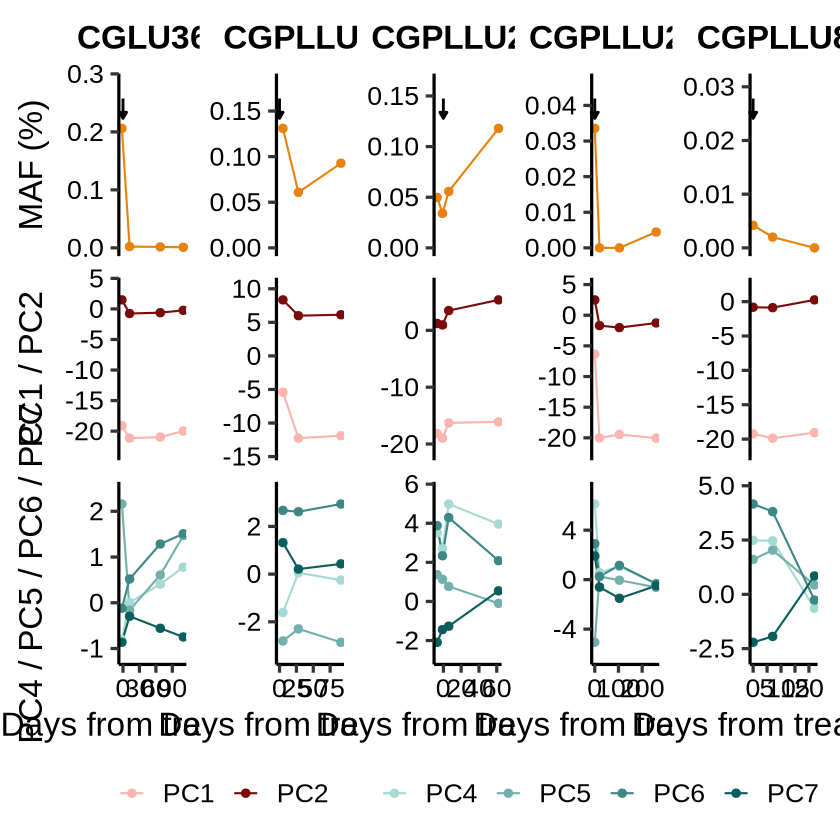

In [6]:
p <- plot_cohort_trajectory(features_df5,
  patient = c("CGLU369", "CGPLLU13", "CGPLLU244", "CGPLLU271", "CGPLLU89"),
  pc_groups = list(
    c("ratio_pc_01", "ratio_pc_02"),
    c("ratio_pc_04", "ratio_pc_05", "ratio_pc_06", "ratio_pc_07")
  ),
  invert_pc = c(TRUE, TRUE, FALSE, FALSE, FALSE, FALSE),
  score_type = "raw",
  base_size = 20)

p


ggsave("../../outputs/Extended/Ext-Data-Fig-7-Longitudinal-Lung-Cancer-Plots.png", p, width = 20, height = 10, dpi = 600)


# Response Plots

In [7]:
library(ggplot2)
library(dplyr)
library(tidyr)
library(colorspace)

plot_response_group_paired_pc <- function(df, pc_col,
                                            patient_col   = "Patient",
                                            days_col      = "Days from Treatment",
                                            response_col  = "Initial radiographic response to treatment",
                                            treatment_day = 0,
                                            target_post_day = NULL,
                                            invert_pc     = FALSE,
                                            score_type    = c("raw", "zscore"),
                                            valid_responses   = NULL,
                                            exclude_responses  = c("Non-measurable*"),
                                            response_order  = NULL,
                                            response_colors = NULL,
                                            group_labels    = NULL,
                                            base_size = 40,
                                            point_size = 6,
                                            p_line_gap = 0.5,
                                            verbose = TRUE) {

  score_type <- match.arg(score_type)
  pc_short_name <- function(col) paste0("PC", as.integer(gsub("\\D", "", col)))

  df <- df %>%
    mutate(.resp_clean = {
      raw <- .data[[response_col]]
      std <- tolower(trimws(as.character(raw)))
      if_else(is.na(raw) | std %in% c("na", "n/a", ""), NA_character_, as.character(raw))
    })

  already_excluded <- character(0)

  if (!is.null(exclude_responses)) {
    exclude_std <- tolower(trimws(exclude_responses))
    excl_patients <- df %>%
      filter(!is.na(.resp_clean), tolower(trimws(.resp_clean)) %in% exclude_std) %>%
      pull(.data[[patient_col]]) %>% unique()
    if (verbose && length(excl_patients) > 0) {
      message(sprintf("Excluding %d patient(s) with response in %s: %s",
                       length(excl_patients), paste(exclude_responses, collapse = "/"),
                       paste(excl_patients, collapse = ", ")))
    }
    already_excluded <- c(already_excluded, excl_patients)
    df <- df %>% mutate(.resp_clean = if_else(tolower(trimws(.resp_clean)) %in% exclude_std, NA_character_, .resp_clean))
  }

  if (!is.null(valid_responses)) {
    valid_std <- tolower(trimws(valid_responses))
    invalid_patients <- df %>%
      filter(!is.na(.resp_clean), !(tolower(trimws(.resp_clean)) %in% valid_std)) %>%
      pull(.data[[patient_col]]) %>% unique()
    invalid_patients <- setdiff(invalid_patients, already_excluded)
    if (verbose && length(invalid_patients) > 0) {
      message(sprintf("Excluding %d patient(s) with response not in valid_responses: %s",
                       length(invalid_patients), paste(invalid_patients, collapse = ", ")))
    }
    already_excluded <- c(already_excluded, invalid_patients)
    df <- df %>% mutate(.resp_clean = if_else(tolower(trimws(.resp_clean)) %in% valid_std, .resp_clean, NA_character_))
  }

  patient_vals <- df %>%
    group_by(.data[[patient_col]]) %>%
    group_modify(~ {
      dd <- .x[order(.x[[days_col]]), ]
      pre  <- dd[dd[[days_col]] <= treatment_day, ]
      post <- dd[dd[[days_col]] >  treatment_day, ]
      if (!is.null(target_post_day)) {
        post <- post[post[[days_col]] >= target_post_day, ]
      }
      base_val <- if (nrow(pre) > 0) tail(pre[[pc_col]], 1) else NA_real_
      post_val <- if (nrow(post) > 0) head(post[[pc_col]], 1) else NA_real_
      if (invert_pc) { base_val <- -1 * base_val; post_val <- -1 * post_val }
      resp <- dplyr::first(na.omit(dd$.resp_clean))
      if (length(resp) == 0) resp <- NA_character_
      tibble(baseline = base_val, post_treatment = post_val, response = resp)
    }) %>%
    ungroup()
  names(patient_vals)[names(patient_vals) == patient_col] <- "Patient"

  if (!is.null(target_post_day) && verbose) {
    no_target_sample <- patient_vals %>%
      filter(!is.na(response), !is.na(baseline), is.na(post_treatment)) %>%
      filter(!(Patient %in% already_excluded)) %>%
      pull(Patient) %>% unique()
    if (length(no_target_sample) > 0) {
      message(sprintf("Dropping %d patient(s) with no post-treatment sample on/after day %g: %s",
                       length(no_target_sample), target_post_day, paste(no_target_sample, collapse = ", ")))
    }
  }

  newly_dropped <- patient_vals %>%
    filter(is.na(response) | is.na(baseline) | is.na(post_treatment)) %>%
    filter(!(Patient %in% already_excluded)) %>%
    pull(Patient) %>% unique()

  if (verbose && length(newly_dropped) > 0 && is.null(target_post_day)) {
    message(sprintf("Dropping %d additional patient(s) with missing response/baseline/post-treatment value: %s",
                     length(newly_dropped), paste(newly_dropped, collapse = ", ")))
  }

  patient_vals <- patient_vals %>% filter(!is.na(response), !is.na(baseline), !is.na(post_treatment))

  if (score_type == "zscore") {
    pool_mean <- mean(c(patient_vals$baseline, patient_vals$post_treatment), na.rm = TRUE)
    pool_sd   <- sd(c(patient_vals$baseline, patient_vals$post_treatment), na.rm = TRUE)
    patient_vals <- patient_vals %>%
      mutate(baseline = (baseline - pool_mean) / pool_sd,
             post_treatment = (post_treatment - pool_mean) / pool_sd)
    y_lab_suffix <- " (z-score)"
  } else {
    y_lab_suffix <- ""
  }

  if (is.null(response_order)) response_order <- sort(unique(patient_vals$response))
  patient_vals$response <- factor(patient_vals$response, levels = response_order)

  if (is.null(response_colors)) {
    response_colors <- setNames(scales::hue_pal()(length(response_order)), response_order)
  }

  # ---- labels shown under each facet (default = auto-capitalized response_order) ----
  auto_cap <- function(x) paste0(toupper(substring(x, 1, 1)), substring(x, 2))
  if (is.null(group_labels)) {
    group_labels <- setNames(sapply(response_order, auto_cap), response_order)
  }

  pvals <- patient_vals %>%
    group_by(response) %>%
    summarise(
      n = n(),
      p = if (n >= 2) suppressWarnings(wilcox.test(baseline, post_treatment, paired = TRUE)$p.value) else NA_real_,
      .groups = "drop"
    ) %>%
    mutate(p_label = case_when(
      is.na(p) ~ "n/a",
      p < 0.001 ~ "P < 0.001",
      TRUE ~ paste0("P = ", sprintf("%.2f", p))
    ))

  long <- patient_vals %>%
    pivot_longer(cols = c(baseline, post_treatment), names_to = "timepoint", values_to = "value") %>%
    mutate(timepoint = factor(timepoint, levels = c("baseline", "post_treatment"),
                               labels = c("Baseline", "Post-tx")))

  light_colors <- setNames(colorspace::lighten(response_colors, amount = 0.45), names(response_colors))
  dark_colors  <- setNames(colorspace::darken(response_colors,  amount = 0.15), names(response_colors))

  long <- long %>%
    mutate(point_color = if_else(timepoint == "Baseline", light_colors[as.character(response)], dark_colors[as.character(response)]))

  y_range <- range(long$value, na.rm = TRUE)
  y_pad <- diff(y_range) * 0.12

  ann_df <- long %>%
    group_by(response) %>%
    summarise(y = max(value, na.rm = TRUE) + y_pad, .groups = "drop") %>%
    left_join(pvals, by = "response")

  pc_lbl <- paste0(pc_short_name(pc_col), y_lab_suffix)
  x_lab_post <- if (!is.null(target_post_day)) paste0("Post-tx", "") else "Post-tx"

  ggplot(long, aes(x = timepoint, y = value, group = Patient)) +
    geom_line(aes(color = response), linewidth = 0.5, alpha = 0.7) +
    geom_point(aes(fill = point_color), shape = 21, color = "white", size = point_size, stroke = 0.3) +
    scale_fill_identity() +
    scale_color_manual(values = response_colors, guide = "none") +
    { if (score_type == "zscore") geom_hline(yintercept = 0, linetype = "dashed", color = "grey60", linewidth = 0.4) } +
    geom_text(data = ann_df, aes(x = 1.5, y = y, label = p_label), inherit.aes = FALSE,
              size = base_size * 0.28, fontface = "italic") +
    geom_segment(data = ann_df, aes(x = 1, xend = 2, y = y - y_pad * p_line_gap, yend = y - y_pad * p_line_gap),
                 inherit.aes = FALSE, linewidth = 0.4, color = "black") +
    scale_x_discrete(labels = c("Baseline" = "Baseline", "Post-tx" = x_lab_post)) +
    facet_wrap(~ response, nrow = 1, scales = "free_x", strip.position = "bottom",
               labeller = labeller(response = group_labels)) +
    labs(x = NULL, y = pc_lbl) +
    coord_cartesian(ylim = c(y_range[1] - y_pad * 0.3, y_range[2] + y_pad * 1.4), clip = "off") +
    theme_classic(base_size = base_size) +
    theme(axis.text = element_text(color = "black"),
          strip.background = element_blank(),
          strip.placement = "outside",
          strip.text = element_text(face = "bold", size = base_size + 1, margin = margin(t = 8)),
          panel.spacing = unit(2, "lines"),
          plot.margin = margin(20, 10, 10, 10))
}


Attaching package: ‘tidyr’


The following object is masked from ‘package:S4Vectors’:

    expand




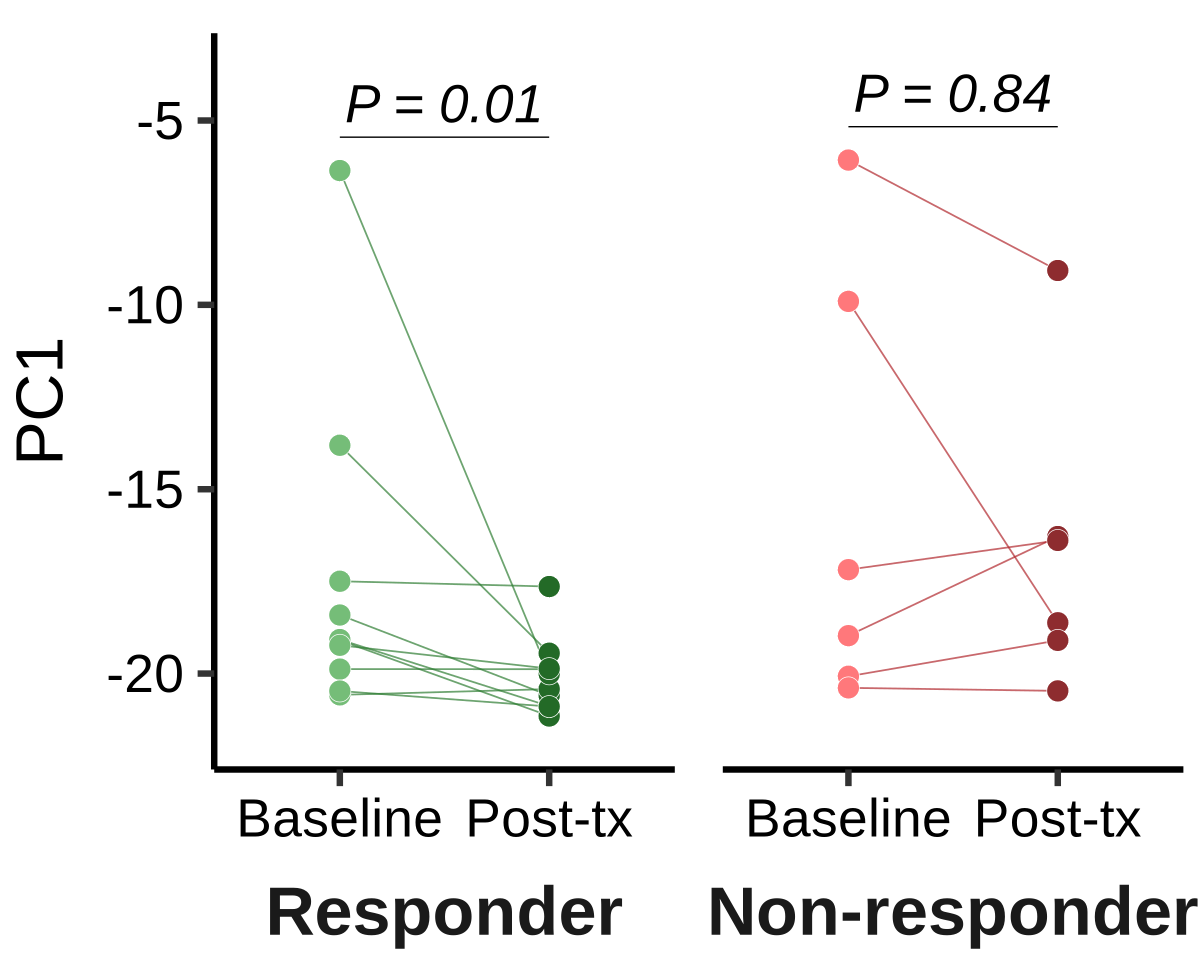

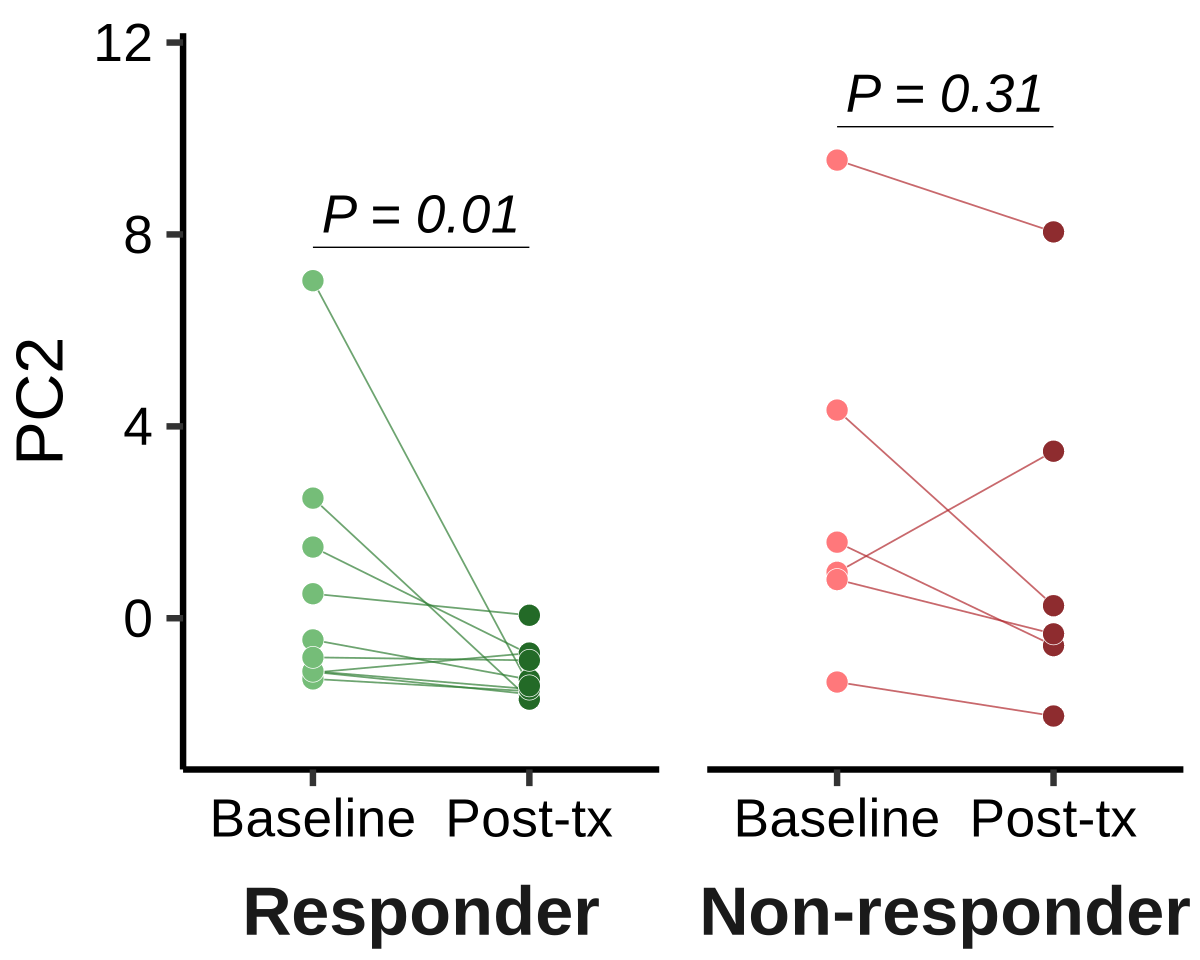

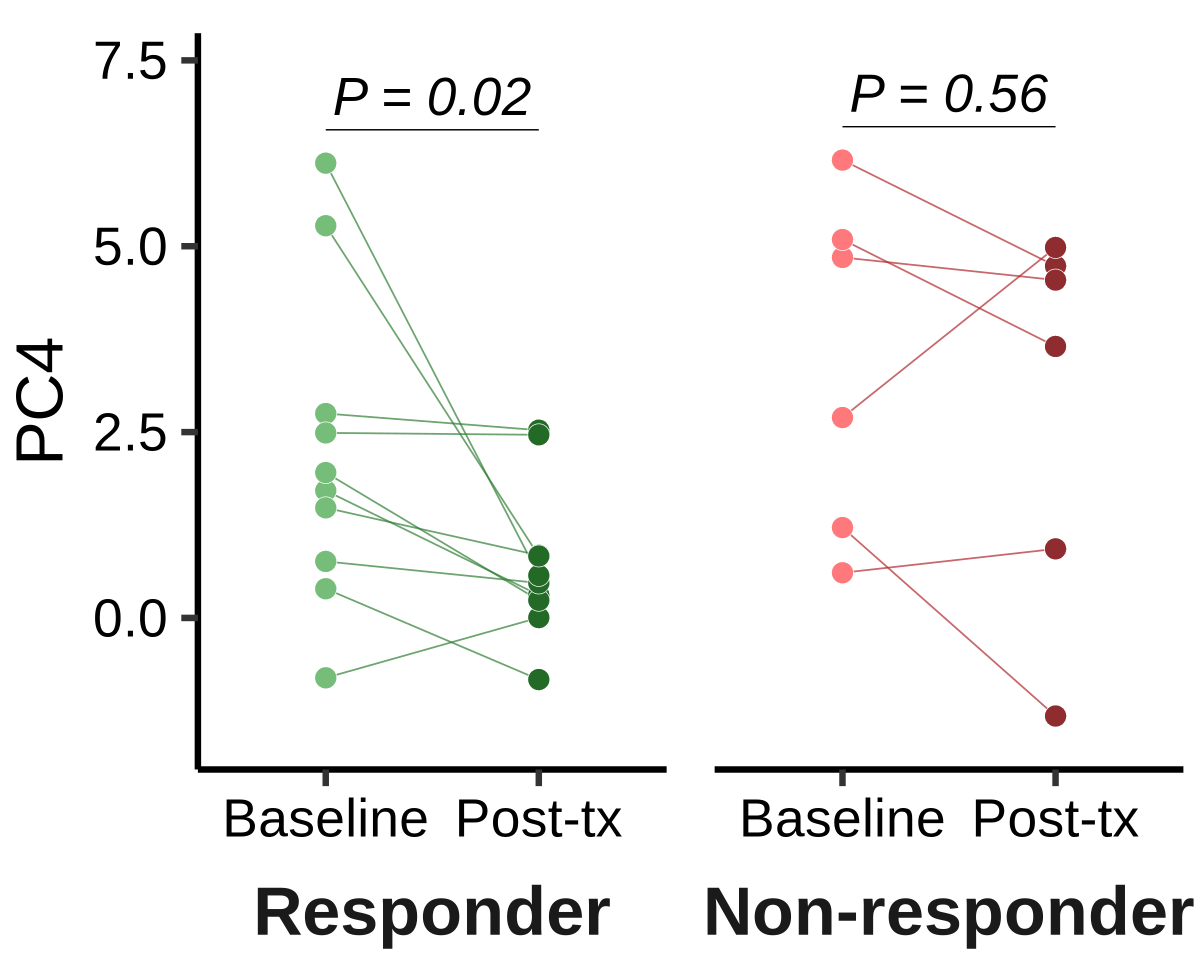

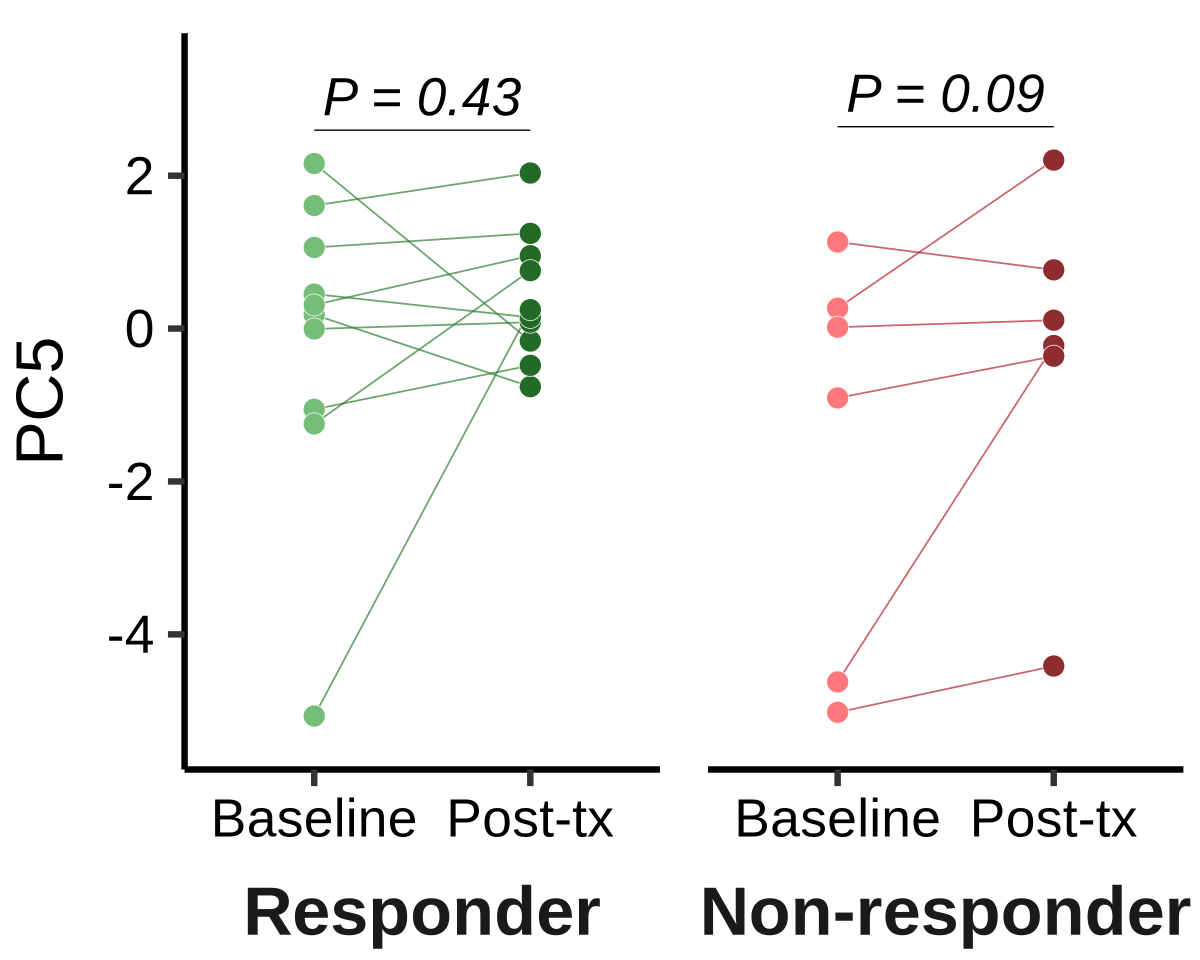

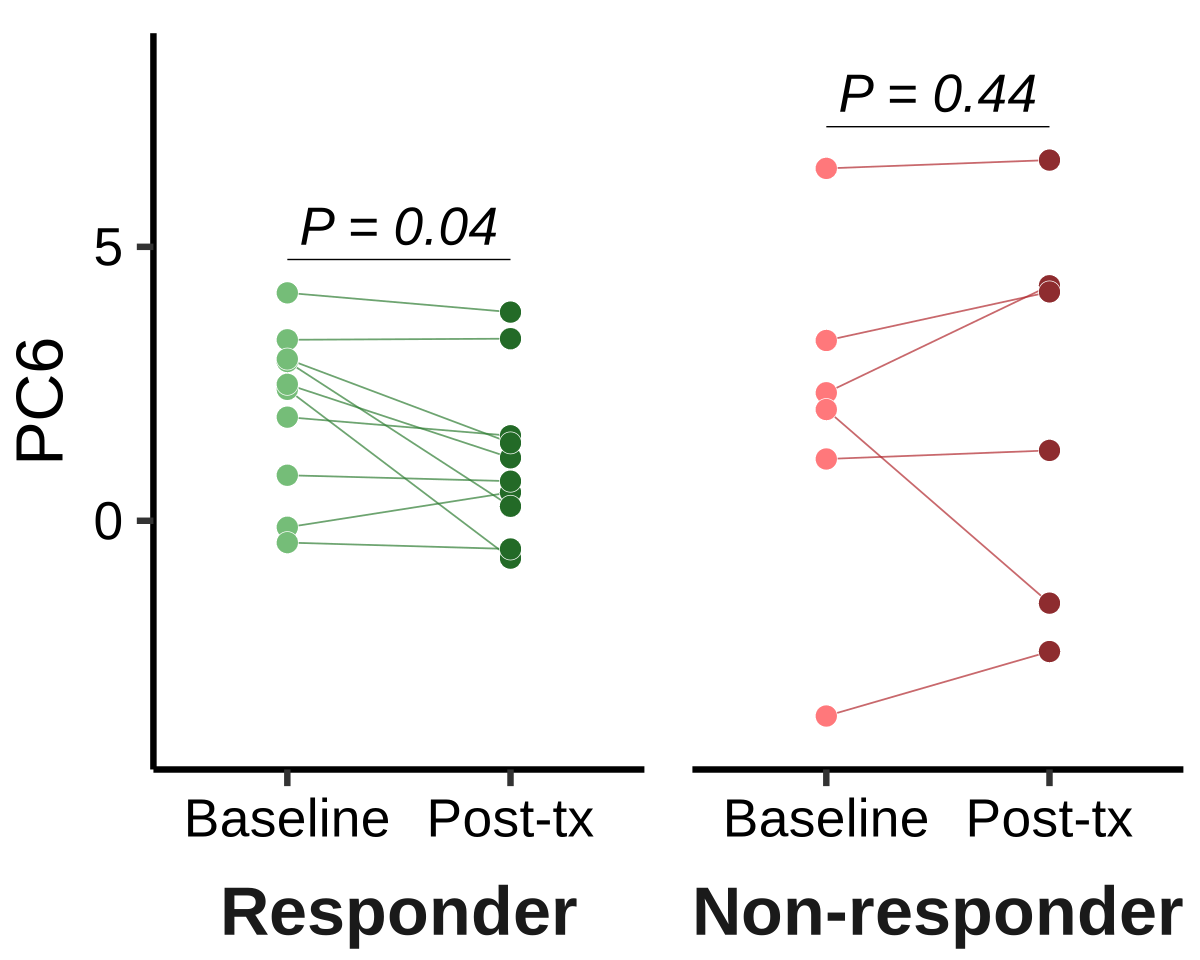

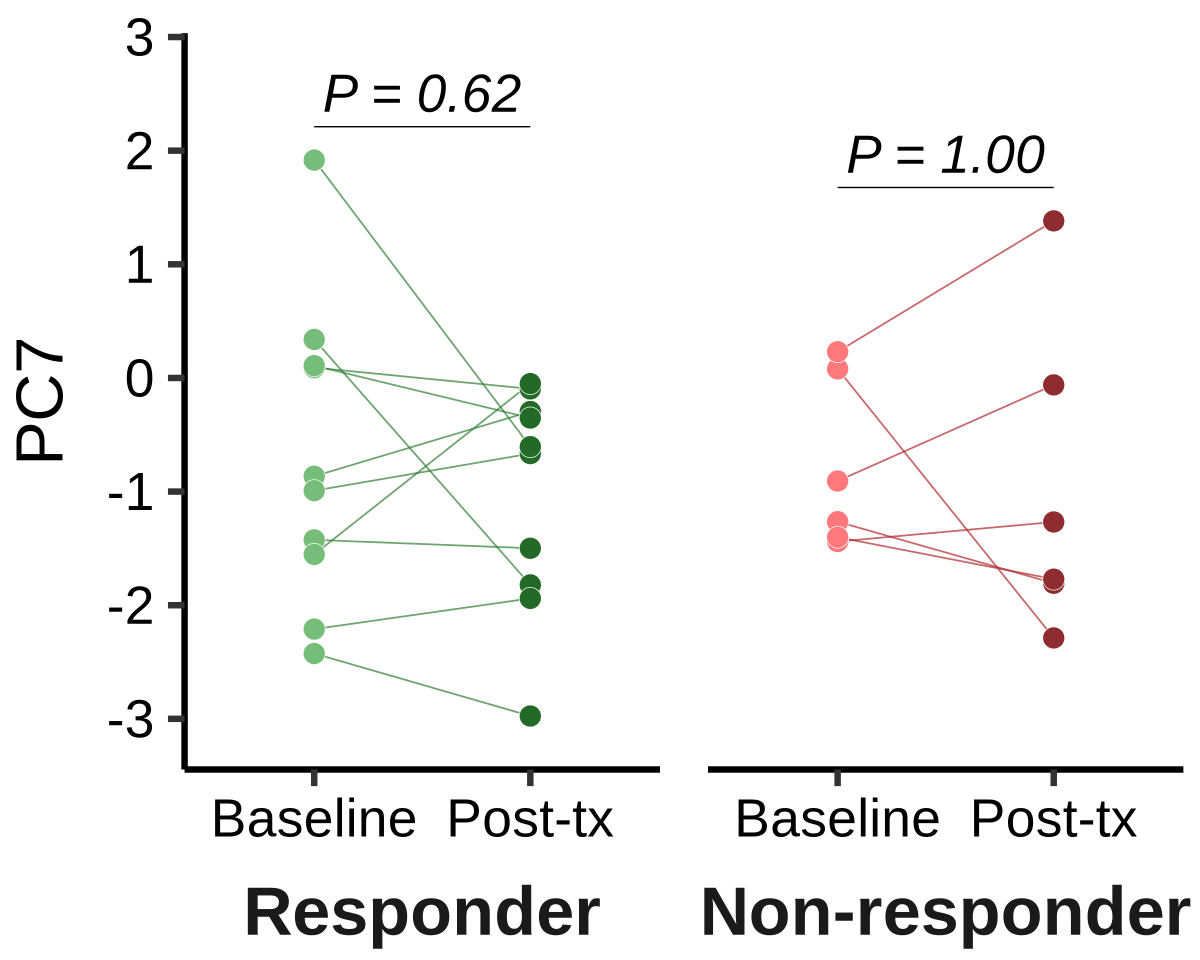

In [8]:
options(repr.plot.width = 10, repr.plot.height = 8, dpi = 600)

p <- plot_response_group_paired_pc(features_df5, pc_col = "ratio_pc_01",
  response_col = "category",
  exclude_responses = NULL,
  response_order  = c("responder", "non-responder"),
  response_colors = c("responder" = "#2E7D32", "non-responder" = "#B0272D"),
  score_type = "raw", invert_pc = TRUE, target_post_day = 1)
p
ggsave("../../outputs/Extended/Ext-Data-Fig-7-Response-PCs/Rev-responder_vs_nonresponder_PC1_d1.png", p, width = 12, height = 9, dpi = 600)



p <- plot_response_group_paired_pc(features_df5, pc_col = "ratio_pc_02",
  response_col = "category",
  exclude_responses = NULL,
  response_order  = c("responder", "non-responder"),
  response_colors = c("responder" = "#2E7D32", "non-responder" = "#B0272D"),
  score_type = "raw", invert_pc = TRUE, target_post_day = 1)
p
ggsave("../../outputs/Extended/Ext-Data-Fig-7-Response-PCs/Rev-responder_vs_nonresponder_PC2_d1.png", p, width = 12, height = 9, dpi = 600)



p <- plot_response_group_paired_pc(features_df5, pc_col = "ratio_pc_04",
  response_col = "category",
  exclude_responses = NULL,
  response_order  = c("responder", "non-responder"),
  response_colors = c("responder" = "#2E7D32", "non-responder" = "#B0272D"),
  score_type = "raw", invert_pc = FALSE, target_post_day = 1)
p
ggsave("../../outputs/Extended/Ext-Data-Fig-7-Response-PCs/Rev-responder_vs_nonresponder_PC4_d1.png", p, width = 12, height = 9, dpi = 600)



p <- plot_response_group_paired_pc(features_df5, pc_col = "ratio_pc_05",
  response_col = "category",
  exclude_responses = NULL,
  response_order  = c("responder", "non-responder"),
  response_colors = c("responder" = "#2E7D32", "non-responder" = "#B0272D"),
  score_type = "raw", invert_pc = FALSE, target_post_day = 1)
p
ggsave("../../outputs/Extended/Ext-Data-Fig-7-Response-PCs/Rev-responder_vs_nonresponder_PC5_d1.png", p, width = 12, height = 9, dpi = 600)



p <- plot_response_group_paired_pc(features_df5, pc_col = "ratio_pc_06",
  response_col = "category",
  exclude_responses = NULL,
  response_order  = c("responder", "non-responder"),
  response_colors = c("responder" = "#2E7D32", "non-responder" = "#B0272D"),
  score_type = "raw", invert_pc = FALSE, target_post_day = 1)
p
ggsave("../../outputs/Extended/Ext-Data-Fig-7-Response-PCs/Rev-responder_vs_nonresponder_PC6_d1.png", p, width = 12, height = 9, dpi = 600)



p <- plot_response_group_paired_pc(features_df5, pc_col = "ratio_pc_07",
  response_col = "category",
  exclude_responses = NULL,
  response_order  = c("responder", "non-responder"),
  response_colors = c("responder" = "#2E7D32", "non-responder" = "#B0272D"),
  score_type = "raw", invert_pc = FALSE, target_post_day = 1)
p
#ggsave("../../outputs/Extended/Ext-Data-Fig-7-Response-PCs/Rev-responder_vs_nonresponder_PC7_d1.png", p, width = 12, height = 9, dpi = 600)

In [9]:
library(ggplot2)
library(dplyr)
library(tidyr)
library(purrr)
library(colorspace)

plot_response_group_paired_pc <- function(df, pc_col,
                                            patient_col   = "Patient",
                                            days_col      = "Days from Treatment",
                                            response_col  = "Initial radiographic response to treatment",
                                            treatment_day = 0,
                                            target_post_days = NULL,     # NULL, single number, or vector e.g. c(7, 21)
                                            invert_pc     = FALSE,
                                            score_type    = c("raw", "zscore"),
                                            valid_responses   = NULL,
                                            exclude_responses  = c("Non-measurable*"),
                                            response_order  = NULL,
                                            response_colors = NULL,
                                            group_labels    = NULL,
                                            base_size = 35,
                                            point_size = 5,
                                            p_line_gap = 0.35,          # spacing between P text and its bracket line
                                            verbose = TRUE) {

  score_type <- match.arg(score_type)
  pc_short_name <- function(col) paste0("PC", as.integer(gsub("\\D", "", col)))

  # ---- build the list of post-treatment "specs" (one per target day, or one generic) ----
  if (is.null(target_post_days)) {
    specs <- list(list(day = NULL, label = "Post-tx"))
  } else {
    specs <- lapply(target_post_days, function(d) list(day = d, label = paste0("Post-tx (day ", d, ")")))
  }
  n_specs <- length(specs)
  post_col_names <- paste0("post_", seq_len(n_specs))

  df <- df %>%
    mutate(.resp_clean = {
      raw <- .data[[response_col]]
      std <- tolower(trimws(as.character(raw)))
      if_else(is.na(raw) | std %in% c("na", "n/a", ""), NA_character_, as.character(raw))
    })

  already_excluded <- character(0)

  if (!is.null(exclude_responses)) {
    exclude_std <- tolower(trimws(exclude_responses))
    excl_patients <- df %>%
      filter(!is.na(.resp_clean), tolower(trimws(.resp_clean)) %in% exclude_std) %>%
      pull(.data[[patient_col]]) %>% unique()
    if (verbose && length(excl_patients) > 0) {
      message(sprintf("Excluding %d patient(s) with response in %s: %s",
                       length(excl_patients), paste(exclude_responses, collapse = "/"),
                       paste(excl_patients, collapse = ", ")))
    }
    already_excluded <- c(already_excluded, excl_patients)
    df <- df %>% mutate(.resp_clean = if_else(tolower(trimws(.resp_clean)) %in% exclude_std, NA_character_, .resp_clean))
  }

  if (!is.null(valid_responses)) {
    valid_std <- tolower(trimws(valid_responses))
    invalid_patients <- df %>%
      filter(!is.na(.resp_clean), !(tolower(trimws(.resp_clean)) %in% valid_std)) %>%
      pull(.data[[patient_col]]) %>% unique()
    invalid_patients <- setdiff(invalid_patients, already_excluded)
    if (verbose && length(invalid_patients) > 0) {
      message(sprintf("Excluding %d patient(s) with response not in valid_responses: %s",
                       length(invalid_patients), paste(invalid_patients, collapse = ", ")))
    }
    already_excluded <- c(already_excluded, invalid_patients)
    df <- df %>% mutate(.resp_clean = if_else(tolower(trimws(.resp_clean)) %in% valid_std, .resp_clean, NA_character_))
  }

  # ---- per-patient baseline & one value per post-treatment spec ----
  patient_vals <- df %>%
    group_by(.data[[patient_col]]) %>%
    group_modify(~ {
      dd <- .x[order(.x[[days_col]]), ]
      pre <- dd[dd[[days_col]] <= treatment_day, ]
      base_val <- if (nrow(pre) > 0) tail(pre[[pc_col]], 1) else NA_real_
      if (invert_pc) base_val <- -1 * base_val

      post_vals <- sapply(specs, function(sp) {
        post <- dd[dd[[days_col]] > treatment_day, ]
        if (!is.null(sp$day)) post <- post[post[[days_col]] >= sp$day, ]
        val <- if (nrow(post) > 0) head(post[[pc_col]], 1) else NA_real_
        if (invert_pc && !is.na(val)) val <- -1 * val
        val
      })

      resp <- dplyr::first(na.omit(dd$.resp_clean))
      if (length(resp) == 0) resp <- NA_character_

      out <- as_tibble(setNames(as.list(post_vals), post_col_names))
      out$baseline <- base_val
      out$response <- resp
      out
    }) %>%
    ungroup()
  names(patient_vals)[names(patient_vals) == patient_col] <- "Patient"

  # ---- only response/baseline are essential; posts may be partially missing ----
  newly_dropped <- patient_vals %>%
    filter(is.na(response) | is.na(baseline)) %>%
    filter(!(Patient %in% already_excluded)) %>%
    pull(Patient) %>% unique()
  if (verbose && length(newly_dropped) > 0) {
    message(sprintf("Dropping %d additional patient(s) with missing response or baseline value: %s",
                     length(newly_dropped), paste(newly_dropped, collapse = ", ")))
  }
  patient_vals <- patient_vals %>% filter(!is.na(response), !is.na(baseline))

  if (verbose) {
    for (i in seq_len(n_specs)) {
      n_missing <- sum(is.na(patient_vals[[post_col_names[i]]]))
      if (n_missing > 0) {
        message(sprintf("Note: %d patient(s) have no value for '%s' (excluded from that comparison only).",
                         n_missing, specs[[i]]$label))
      }
    }
  }

  # ---- optional z-scoring: pooled distribution across baseline + all post columns ----
  all_val_cols <- c("baseline", post_col_names)
  if (score_type == "zscore") {
    pool_vals <- unlist(patient_vals[all_val_cols], use.names = FALSE)
    pool_mean <- mean(pool_vals, na.rm = TRUE)
    pool_sd   <- sd(pool_vals, na.rm = TRUE)
    patient_vals <- patient_vals %>%
      mutate(across(all_of(all_val_cols), ~ (. - pool_mean) / pool_sd))
    y_lab_suffix <- " (z-score)"
  } else {
    y_lab_suffix <- ""
  }

  if (is.null(response_order)) response_order <- sort(unique(patient_vals$response))
  patient_vals$response <- factor(patient_vals$response, levels = response_order)

  if (is.null(response_colors)) {
    response_colors <- setNames(scales::hue_pal()(length(response_order)), response_order)
  }

  auto_cap <- function(x) paste0(toupper(substring(x, 1, 1)), substring(x, 2))
  if (is.null(group_labels)) {
    group_labels <- setNames(sapply(response_order, auto_cap), response_order)
  }

  # ---- paired Wilcoxon: baseline vs EACH post-treatment spec, per response group ----
  pvals <- map_dfr(seq_len(n_specs), function(i) {
    col <- post_col_names[i]
    patient_vals %>%
      group_by(response) %>%
      summarise(
        n = sum(complete.cases(baseline, .data[[col]])),
        p = if (n >= 2) suppressWarnings(wilcox.test(baseline[complete.cases(baseline, .data[[col]])],
                                                        .data[[col]][complete.cases(baseline, .data[[col]])],
                                                        paired = TRUE)$p.value) else NA_real_,
        .groups = "drop"
      ) %>%
      mutate(spec_index = i, label = specs[[i]]$label)
  }) %>%
    mutate(p_label = case_when(
      is.na(p) ~ "n/a",
      p < 0.001 ~ "P < 0.001",
      TRUE ~ paste0("P = ", sprintf("%.2f", p))
    ))

  # ---- long format for plotting ----
  timepoint_levels <- c("Baseline", sapply(specs, function(s) s$label))
  long <- patient_vals %>%
    pivot_longer(cols = all_of(all_val_cols), names_to = "timepoint_key", values_to = "value") %>%
    mutate(timepoint = case_when(
      timepoint_key == "baseline" ~ "Baseline",
      TRUE ~ sapply(specs, function(s) s$label)[match(timepoint_key, post_col_names)]
    )) %>%
    mutate(timepoint = factor(timepoint, levels = timepoint_levels))

  ramp_shade <- function(resp, tp_index, n_tp) {
    frac <- if (n_tp <= 1) 1 else (tp_index - 1) / (n_tp - 1)
    colorspace::lighten(response_colors[[resp]], amount = 0.45 * (1 - frac))
  }
  long <- long %>%
    rowwise() %>%
    mutate(point_color = ramp_shade(as.character(response), as.integer(timepoint), length(timepoint_levels))) %>%
    ungroup()

  y_range <- range(long$value, na.rm = TRUE)
  y_pad <- diff(y_range) * 0.14

  # ---- annotation brackets: one per spec, stacked at increasing heights ----
  y_max <- max(long$value, na.rm = TRUE)
  ann_df <- pvals %>%
    mutate(x = 1, xend = 1 + spec_index, y = y_max + y_pad * spec_index)

  pc_lbl <- paste0(pc_short_name(pc_col), y_lab_suffix)
  y_top <- y_max + y_pad * (n_specs + 1.3)
  y_bottom <- y_range[1] - y_pad * 0.3

  # ---- x-axis tick labels: "Baseline" stays; post-tx ticks show "+" + day number ----
  axis_labels <- setNames(
    c("Baseline", sapply(specs, function(s) if (!is.null(s$day)) paste0("+", s$day) else s$label)),
    timepoint_levels
  )

  ggplot(long, aes(x = timepoint, y = value, group = Patient)) +
    geom_line(aes(color = response), linewidth = 0.5, alpha = 0.7, na.rm = TRUE) +
    geom_point(aes(fill = point_color), shape = 21, color = "white", size = point_size, stroke = 0.3, na.rm = TRUE) +
    scale_fill_identity() +
    scale_color_manual(values = response_colors, guide = "none") +
    { if (score_type == "zscore") geom_hline(yintercept = 0, linetype = "dashed", color = "grey60", linewidth = 0.4) } +
    geom_text(data = ann_df, aes(x = (x + xend) / 2, y = y + y_pad * p_line_gap, label = p_label), inherit.aes = FALSE,
              size = base_size * 0.24, fontface = "italic") +
    geom_segment(data = ann_df, aes(x = x, xend = xend, y = y, yend = y),
                 inherit.aes = FALSE, linewidth = 0.4, color = "black") +
    scale_x_discrete(labels = axis_labels) +
    facet_wrap(~ response, nrow = 1, scales = "free_x", strip.position = "bottom",
               labeller = labeller(response = group_labels)) +
    labs(x = NULL, y = pc_lbl) +
    coord_cartesian(ylim = c(y_bottom, y_top), clip = "off") +
    theme_classic(base_size = base_size) +
    theme(axis.text = element_text(color = "black"),
          axis.text.x = element_text(angle = 0, hjust = 0.5, vjust = 1),
          strip.background = element_blank(),
          strip.placement = "outside",
          strip.text = element_text(face = "bold", size = base_size + 1, margin = margin(t = 8)),
          panel.spacing = unit(2, "lines"),
          plot.margin = margin(20, 10, 10, 10))
}


Attaching package: ‘purrr’


The following object is masked from ‘package:GenomicRanges’:

    reduce


The following object is masked from ‘package:IRanges’:

    reduce




Dropping 3 additional patient(s) with missing response or baseline value: CGPLLU13, CGPLLU266, CGPLLU43

Note: 2 patient(s) have no value for 'Post-tx (day 21)' (excluded from that comparison only).

Note: 5 patient(s) have no value for 'Post-tx (day 35)' (excluded from that comparison only).

Dropping 3 additional patient(s) with missing response or baseline value: CGPLLU13, CGPLLU266, CGPLLU43

Note: 2 patient(s) have no value for 'Post-tx (day 21)' (excluded from that comparison only).

Note: 5 patient(s) have no value for 'Post-tx (day 35)' (excluded from that comparison only).



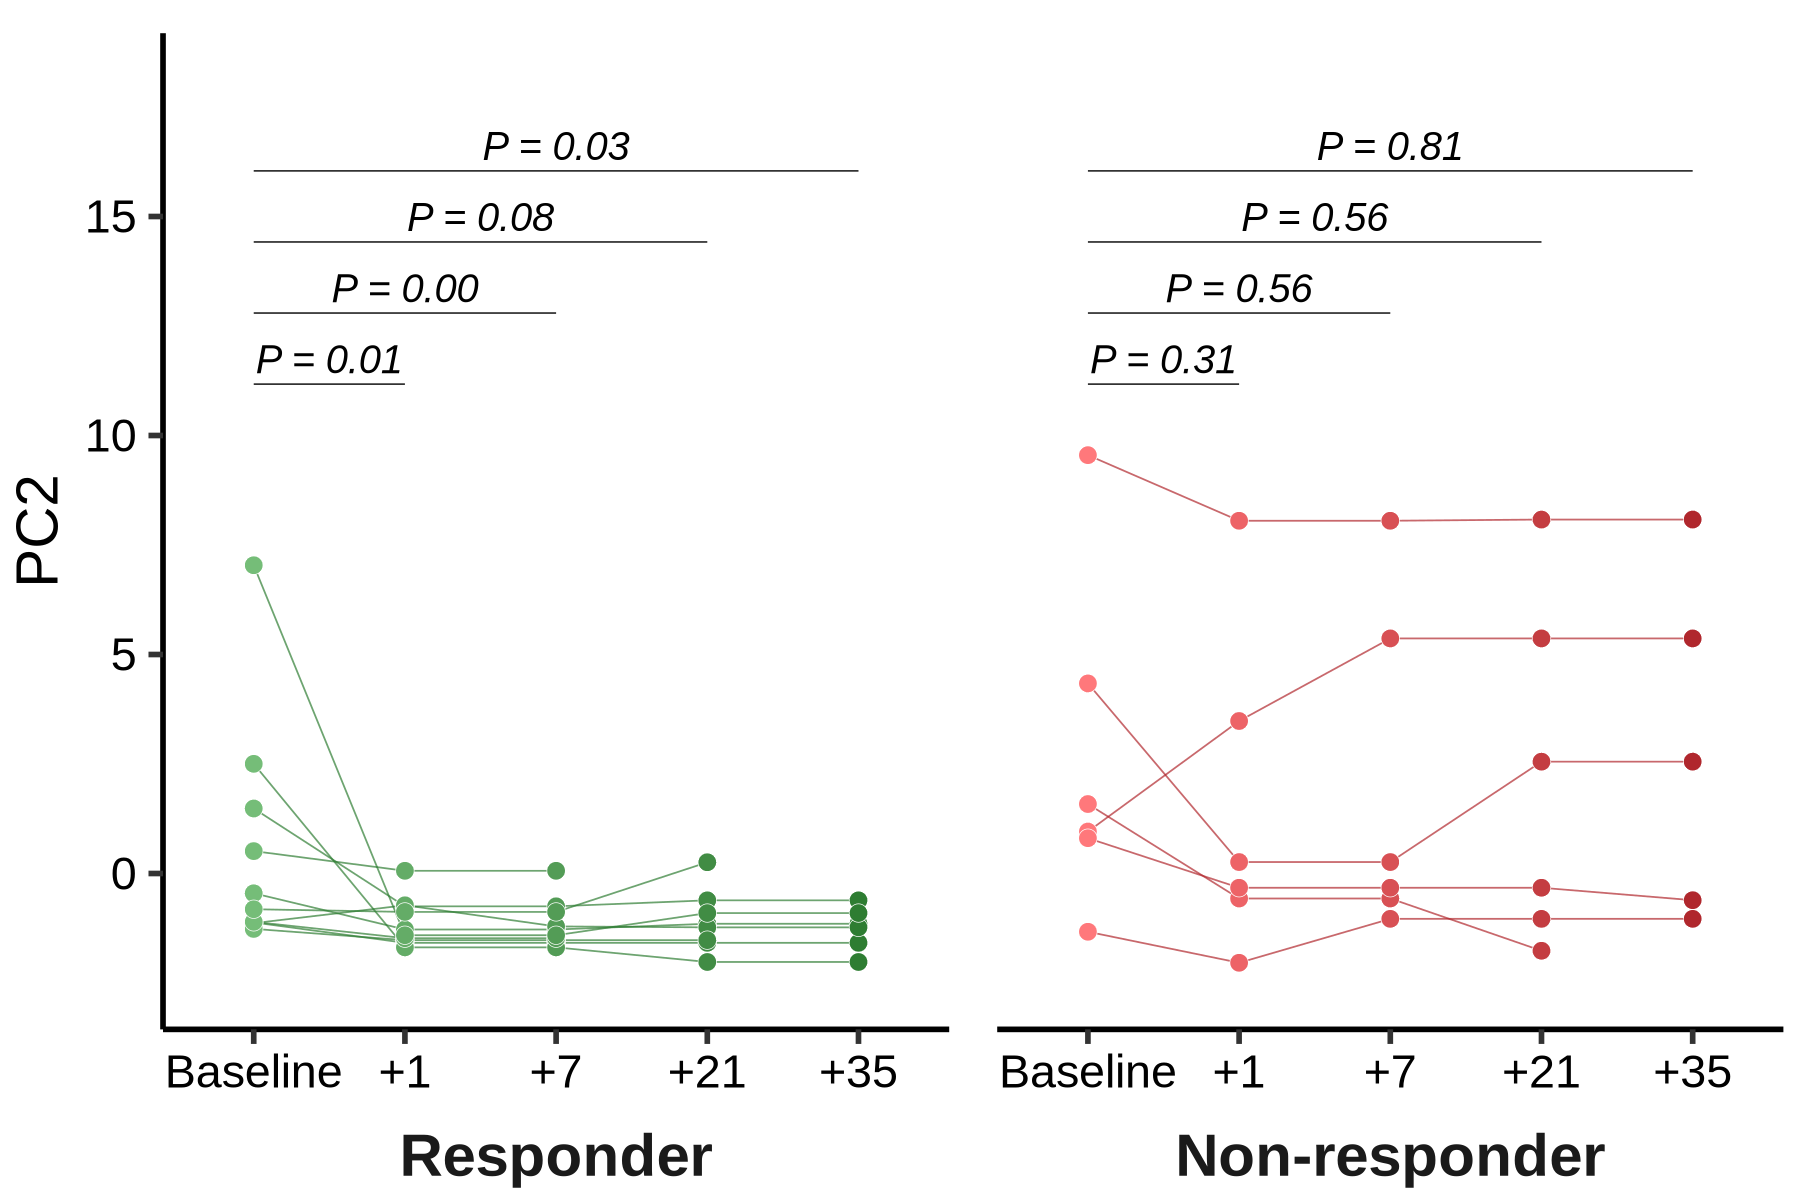

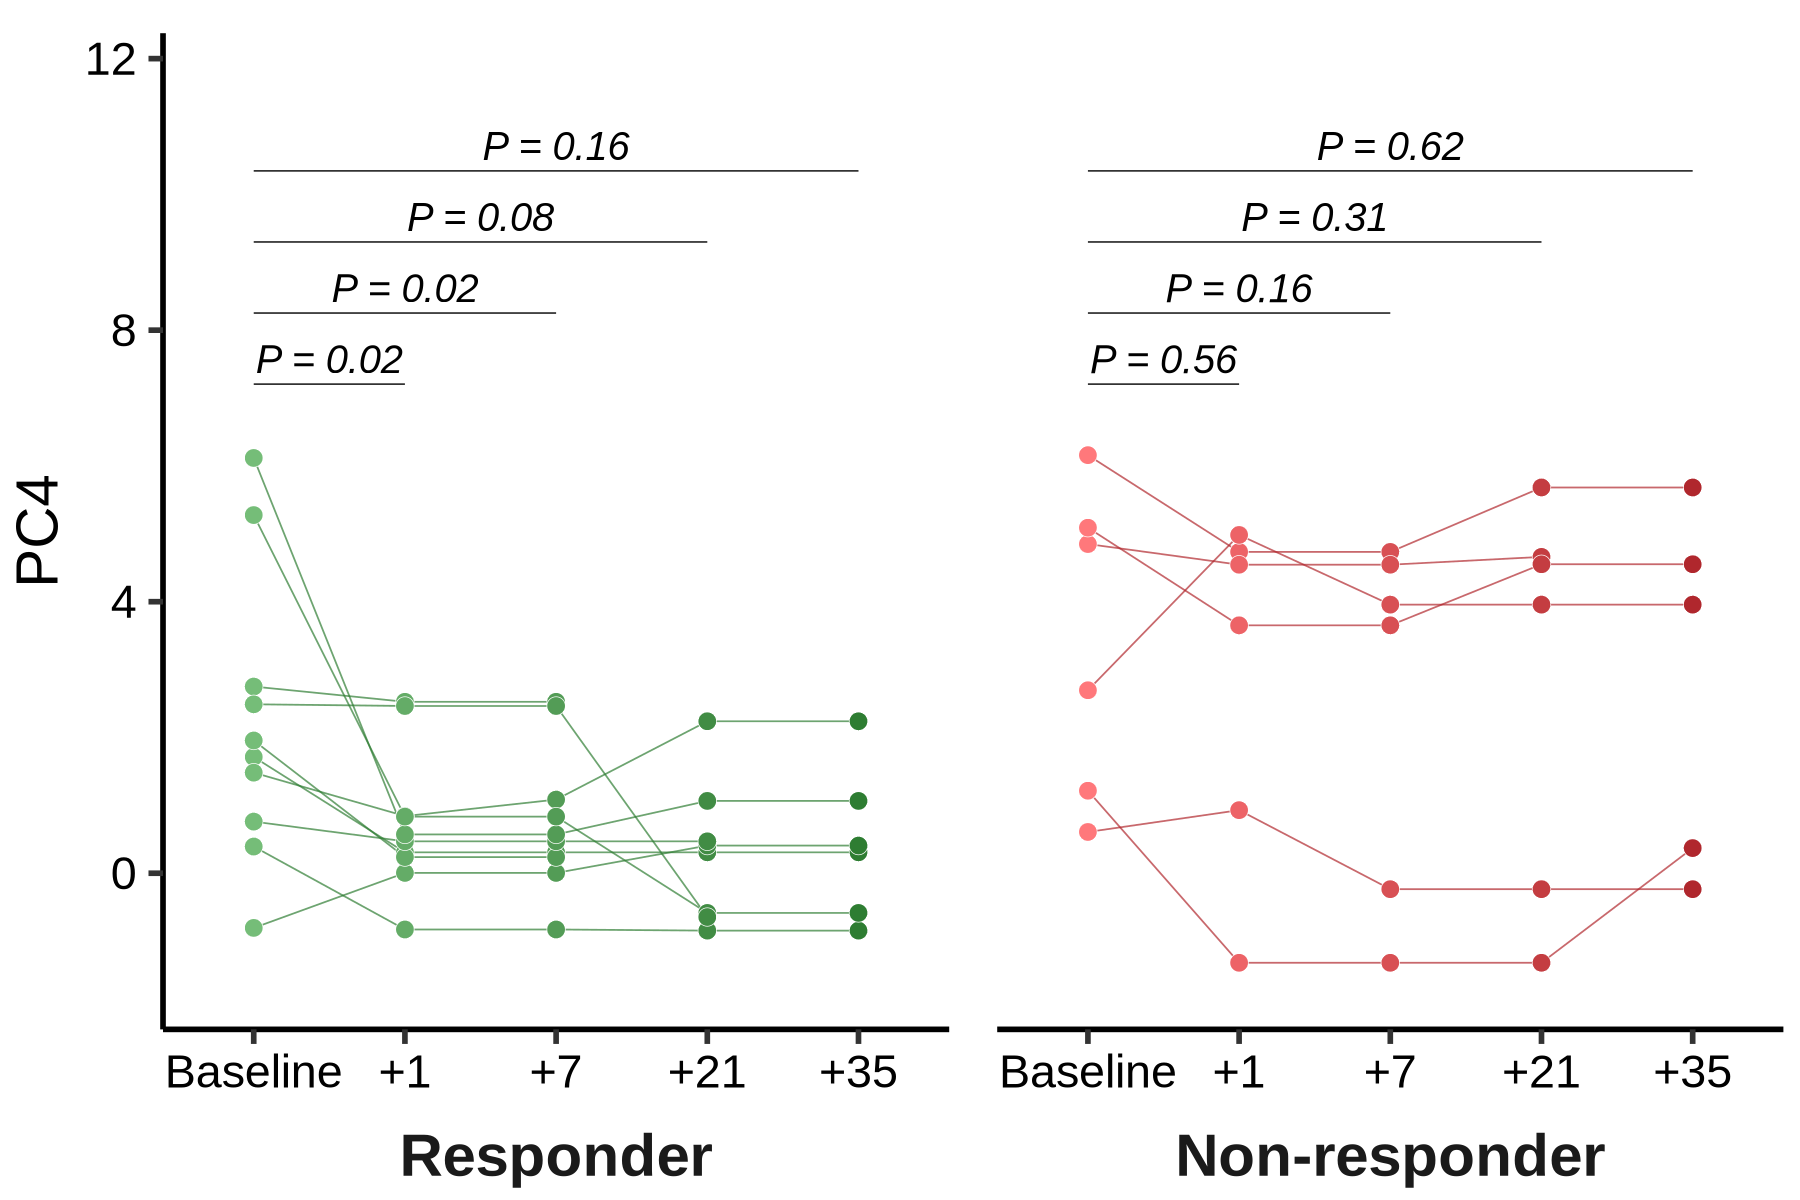

In [10]:
options(repr.plot.width = 15, repr.plot.height = 10, dpi = 600)

p <- plot_response_group_paired_pc(features_df5, pc_col = "ratio_pc_02",
  response_col = "category",
  exclude_responses = NULL,
  response_order  = c("responder", "non-responder"),
  response_colors = c("responder" = "#2E7D32", "non-responder" = "#B0272D"),
  target_post_days = c(1, 7, 21, 35),
  score_type = "raw", invert_pc = TRUE)
p
ggsave("../../outputs/Extended/Ext-Data-Fig-7-responder_vs_nonresponder_PC2_multitp.png", p, width = 16, height = 10, dpi = 600)

options(repr.plot.width = 15, repr.plot.height = 10, dpi = 600)

p <- plot_response_group_paired_pc(features_df5, pc_col = "ratio_pc_04",
  response_col = "category",
  exclude_responses = NULL,
  response_order  = c("responder", "non-responder"),
  response_colors = c("responder" = "#2E7D32", "non-responder" = "#B0272D"),
  target_post_days = c(1, 7, 21, 35),
  score_type = "raw", invert_pc = FALSE)
p
ggsave("../../outputs/Extended/Ext-Data-Fig-7-responder_vs_nonresponder_PC4_multitp.png", p, width = 16, height = 10, dpi = 600)





In [ ]:
# Done #